# RLI Assignment 22.00: Mountain Car

## Setup & Dependencies


In [1]:
# Uncomment to install dependencies (all should be present in the project venv)
# !pip install gymnasium stable-baselines3 torch matplotlib numpy pandas seaborn tensorboard

# Library versions used:
# gymnasium==1.2.3, stable-baselines3==2.8.0, torch==2.10.0, numpy==2.2.6


In [2]:
import sys
sys.path.insert(0, '.')

import mclib as mc

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import seaborn as sns
import time, random, warnings
warnings.filterwarnings('ignore')

import gymnasium as gym
import torch

from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 4)

print("Setup complete.")


Setup complete.


## 1. Environment Analysis

### 1.1 The Mountain Car Problem

In [3]:
# Explore both environment versions
env_disc = gym.make('MountainCar-v0')
env_cont = gym.make('MountainCarContinuous-v0')

print("DISCRETE: MountainCar-v0")
print(f"Action space: {env_disc.action_space}")
print(f"Observation space: {env_disc.observation_space}")
print(f"Obs low: {env_disc.observation_space.low}")
print(f"Obs high: {env_disc.observation_space.high}")

print("\nCONTINUOUS: MountainCarContinuous-v0")
print(f"Action space: {env_cont.action_space}")
print(f"Observation space: {env_cont.observation_space}")

env_disc.close()
env_cont.close()


DISCRETE: MountainCar-v0
Action space: Discrete(3)
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Obs low: [-1.2  -0.07]
Obs high: [0.6  0.07]

CONTINUOUS: MountainCarContinuous-v0
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)


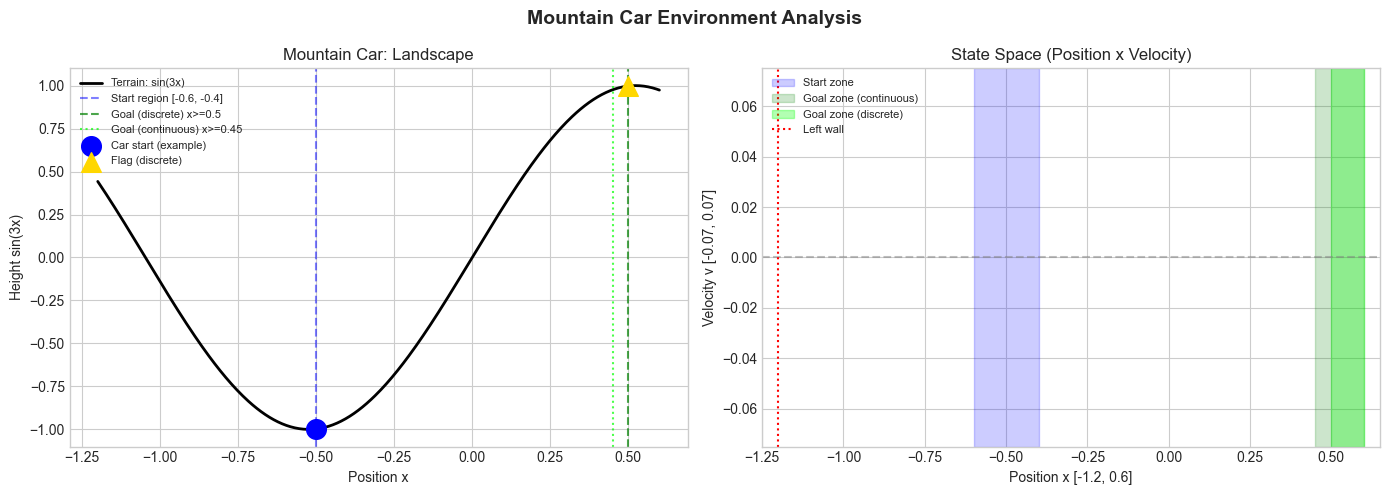

In [ ]:
# Visualize the landscape and phase portrait concept
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Mountain Car landscape
x = np.linspace(-1.2, 0.6, 400)
y = np.sin(3 * x)  # height profile

ax = axes[0]
ax.plot(x, y, 'k-', linewidth=2, label='Terrain: sin(3x)')
ax.axvline(-0.5, color='blue', linestyle='--', alpha=0.5, label='Start region [-0.6, -0.4]')
ax.axvline(0.5,  color='green', linestyle='--', alpha=0.7, label='Goal (discrete) x>=0.5')
ax.axvline(0.45, color='lime',  linestyle=':',  alpha=0.7, label='Goal (continuous) x>=0.45')
ax.scatter([-0.5], [np.sin(-1.5)], s=200, c='blue',  zorder=5, label='Car start (example)')
ax.scatter([0.5],  [np.sin(1.5)],  s=200, c='gold', marker='^', zorder=5, label='Flag (discrete)')
ax.set_xlabel('Position x')
ax.set_ylabel('Height sin(3x)')
ax.set_title('Mountain Car: Landscape')
ax.legend(fontsize=8, loc='upper left')

# Right: State space boundaries
ax2 = axes[1]
ax2.set_xlim(-1.25, 0.65)
ax2.set_ylim(-0.075, 0.075)

# Shade the starting zone
ax2.axvspan(-0.6, -0.4, alpha=0.2, color='blue', label='Start zone')
ax2.axvspan(0.45, 0.6, alpha=0.2, color='green', label='Goal zone (continuous)')
ax2.axvspan(0.5, 0.6, alpha=0.3, color='lime', label='Goal zone (discrete)')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(-1.2, color='red', linestyle=':', label='Left wall')
ax2.set_xlabel('Position x [-1.2, 0.6]')
ax2.set_ylabel('Velocity v [-0.07, 0.07]')
ax2.set_title('State Space (Position x Velocity)')
ax2.legend(fontsize=8)

plt.suptitle('Mountain Car Environment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Scenario 1: Discrete Minimum Steps

**Design Choices**
- State representation: 
- Rewards:
- Algorithms:
- Training strategy: 
- Custom Wrappers: 
- Hyperparameters:
- Objective performance vs engineered reward:

In [5]:
# Scenario 1 — sanity check: MountainCar-v0 default reward
env = mc.make_s1()
obs, _ = env.reset(seed=0)
print(f"Observation space : {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Initial obs: {obs}")
obs2, r, term, trunc, _ = env.step(2)
print(f"Default reward for action=2: {r}  (should be -1.0)")
env.close()


Observation space : Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Initial obs: [-0.47260767  0.        ]
Default reward for action=2: -1.0  (should be -1.0)


### Model 1: Tabular Q-Learning (default hyperparameters)

In [6]:
s1_ql_agent = mc.TabularQLearningAgent(n_bins=40, alpha=0.15, gamma=0.99, eps_start=1.0,  eps_end=0.01, eps_decay=0.9997 )

with mc.Testbed('S1/QL_default', log_dir='runs') as tb:
    s1_ql_results = tb.run_tabular(mc.make_s1, s1_ql_agent, n_episodes=15_000, eval_every=2_000,n_eval=50, verbose=True)

s1_ql_rewards = s1_ql_results['rewards']
s1_ql_eval_means = s1_ql_results['eval_means']
s1_ql_eval_stds = s1_ql_results['eval_stds']
s1_ql_eval_eps = s1_ql_results['eval_episodes']
s1_ql_final = s1_ql_results['final']
print(f"\nQL default — mean={np.mean(s1_ql_final):.2f} +/- {np.std(s1_ql_final):.2f} | "
      f"success={np.mean(np.array(s1_ql_final) > -200):.1%}")


[Testbed] 'S1/QL_default' — logs -> runs\S1_QL_default
  Ep   2000 | train_r= -200.0 | eval_mean=-200.00 +/- 0.00 | eps=0.549
  Ep   4000 | train_r= -166.0 | eval_mean=-184.82 +/- 17.09 | eps=0.301
  Ep   6000 | train_r= -200.0 | eval_mean=-186.66 +/- 18.82 | eps=0.165
  Ep   8000 | train_r= -200.0 | eval_mean=-147.38 +/- 13.90 | eps=0.091
  Ep  10000 | train_r= -153.0 | eval_mean=-140.86 +/- 20.63 | eps=0.050
  Ep  12000 | train_r= -141.0 | eval_mean=-136.94 +/- 25.19 | eps=0.027
  Ep  14000 | train_r= -186.0 | eval_mean=-132.96 +/- 26.29 | eps=0.015
[Testbed] Final eval — mean=-145.32 +/- 26.45 | success=100.0%
[Testbed] 'S1/QL_default' closed.

QL default — mean=-145.32 +/- 26.45 | success=100.0%


In [ ]:
# Launch TensorBoard to compare all S1 runs
# Run this in a terminal (not in the notebook):
#      tensorboard --logdir runs
# Then open http://localhost:6006 in your browser.


## 3. Scenario 2: Continuous and Minimum Fuel


**Design Choices**
- State representation: 
- Rewards:
- Algorithms:
- Training strategy: 
- Custom Wrappers: 
- Hyperparameters:
- Objective performance vs engineered reward:

## 4. Scenario 3: Discrete Adapted and Minimum Fuel

**Design Choices**
- State representation: 
- Rewards:
- Algorithms:
- Training strategy: 
- Custom Wrappers: 
- Hyperparameters:
- Objective performance vs engineered reward:

## 5. Scenario 4: Continuous Adapted and Minimum Steps

**Design Choices**
- State representation: 
- Rewards:
- Algorithms:
- Training strategy: 
- Custom Wrappers: 
- Hyperparameters:
- Objective performance vs engineered reward:

## 6. Comparative Analysis

## 7. Explanation Tools